# Deep Learning - Artificial Neural Networks  - Derin Öğrenme Yapay Sinir Ağları
Bugün insan beyninin öğrenme modelini taklit eden yapay sinir ağlarını derinlemesine öğreneceğiz
### Classification


In [46]:
import pandas as pd

In [47]:
df=pd.read_csv('pima-indians-diabetes.csv')

In [48]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [49]:
df.shape


(768, 9)

In [50]:
# Classification - Evet Hayır sorularının sorulduğu - Şeker hastası mı / değil mi?


In [51]:
df.isnull().sum() # boş veri var mı / yok mu kontrol ediyoruz

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [52]:
pip install tensorflow # çok boyutlu matris


In [53]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [54]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [55]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]

In [56]:
y=df[['Outcome']]

In [57]:
x=df.drop('Outcome', axis=1)
y=df[['Outcome']]

In [58]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [59]:
x=df.iloc[:,0:8] # ilk 8 sutunu secer
y=df.iloc[:,8] # 8 den sonraki sutunlari secer

In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [61]:
model=Sequential()
model.add(Dense(80,activation='relu')) # hayal urunu
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [62]:
history=model.fit(x,y,batch_size=32, validation_split=0.10,verbose=2, epochs=100)


Epoch 1/100
22/22 - 3s - 127ms/step - accuracy: 0.5456 - loss: 1.6855 - val_accuracy: 0.5714 - val_loss: 0.7720
Epoch 2/100
22/22 - 0s - 14ms/step - accuracy: 0.6599 - loss: 0.6292 - val_accuracy: 0.6104 - val_loss: 0.6554
Epoch 3/100
22/22 - 0s - 13ms/step - accuracy: 0.6744 - loss: 0.6102 - val_accuracy: 0.5844 - val_loss: 0.8378
Epoch 4/100
22/22 - 0s - 13ms/step - accuracy: 0.6990 - loss: 0.6008 - val_accuracy: 0.7013 - val_loss: 0.6270
Epoch 5/100
22/22 - 0s - 12ms/step - accuracy: 0.6975 - loss: 0.6029 - val_accuracy: 0.5714 - val_loss: 0.6815
Epoch 6/100
22/22 - 0s - 12ms/step - accuracy: 0.7091 - loss: 0.5813 - val_accuracy: 0.6623 - val_loss: 0.6350
Epoch 7/100
22/22 - 0s - 15ms/step - accuracy: 0.6975 - loss: 0.6025 - val_accuracy: 0.6494 - val_loss: 0.6747
Epoch 8/100
22/22 - 0s - 13ms/step - accuracy: 0.6932 - loss: 0.5838 - val_accuracy: 0.5844 - val_loss: 0.6996
Epoch 9/100
22/22 - 0s - 10ms/step - accuracy: 0.7265 - loss: 0.5735 - val_accuracy: 0.5844 - val_loss: 0.8816


In [63]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 80)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 120)            │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 30)             │         1,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,175 (238.97 KB)

 Trainable params: 20,391 (79.65 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,784 (159.32 KB)

In [64]:
loss, accuracy=model.evaluate(x,y)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7539 - loss: 0.5005 


In [65]:
accuracy

0.75390625

In [66]:
from sklearn.preprocessing import StandardScaler

In [67]:
scaler=StandardScaler()

In [68]:
x=scaler.fit_transform(x)

In [69]:
history=model.fit(x,y,batch_size=32, validation_split=0.10,verbose=2, epochs=100)

Epoch 1/100
22/22 - 0s - 7ms/step - accuracy: 0.6628 - loss: 0.6200 - val_accuracy: 0.6104 - val_loss: 0.6275
Epoch 2/100
22/22 - 0s - 8ms/step - accuracy: 0.7192 - loss: 0.5176 - val_accuracy: 0.7922 - val_loss: 0.5221
Epoch 3/100
22/22 - 0s - 8ms/step - accuracy: 0.7771 - loss: 0.4672 - val_accuracy: 0.8182 - val_loss: 0.5029
Epoch 4/100
22/22 - 0s - 7ms/step - accuracy: 0.7858 - loss: 0.4437 - val_accuracy: 0.7792 - val_loss: 0.5144
Epoch 5/100
22/22 - 0s - 7ms/step - accuracy: 0.7931 - loss: 0.4281 - val_accuracy: 0.8182 - val_loss: 0.5086
Epoch 6/100
22/22 - 0s - 9ms/step - accuracy: 0.7931 - loss: 0.4259 - val_accuracy: 0.8312 - val_loss: 0.5112
Epoch 7/100
22/22 - 0s - 10ms/step - accuracy: 0.8032 - loss: 0.4068 - val_accuracy: 0.8312 - val_loss: 0.5252
Epoch 8/100
22/22 - 0s - 8ms/step - accuracy: 0.8177 - loss: 0.4015 - val_accuracy: 0.8182 - val_loss: 0.5233
Epoch 9/100
22/22 - 0s - 14ms/step - accuracy: 0.8177 - loss: 0.3913 - val_accuracy: 0.8571 - val_loss: 0.5369
Epoch 10

In [70]:
loss, accuracy=model.evaluate(x,y)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9779 - loss: 0.3185 


In [71]:
accuracy

0.9778645634651184

In [72]:
import matplotlib.pyplot as plt

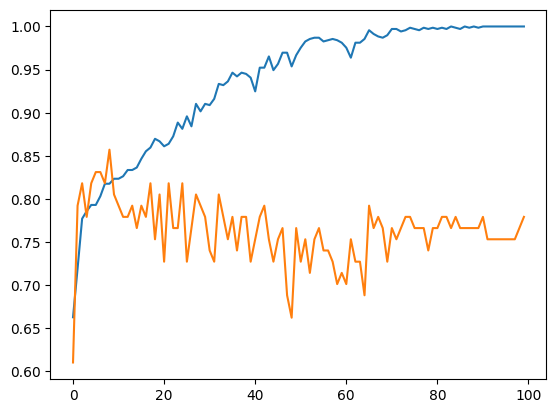

In [73]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

### Regression

In [74]:
df=pd.read_pickle('kc_house.pkl')

In [75]:
df.head()

,bedrooms,bathrooms,sqft_living,grade,view,basement,waterfront,floors,age,renovated,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,9,1.0000,1180,7,0,0,0,1.0,65,0,...,0,0,0,0,0,0,1,0,0,0
1,9,5.0625,2570,7,0,1,0,2.0,69,1,...,0,0,0,0,0,0,0,0,0,0
2,4,1.0000,770,6,0,0,0,1.0,87,0,...,0,0,0,0,0,0,0,0,0,0
3,16,9.0000,1960,7,0,1,0,1.0,55,0,...,0,0,0,0,0,0,0,0,0,0
4,9,4.0000,1680,8,0,0,0,1.0,33,0,...,0,0,0,0,0,0,0,0,0,0


In [76]:
x=df.drop('price' ,axis=1)
y=df[['price']]

In [77]:
x=scaler.fit_transform(x)

In [78]:
model=Sequential()
model.add(Dense(80,activation='relu')) # hayal urunu
model.add(Dense(120,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(1)) #sigmoid yok
model.compile(loss='mean_squared_error', optimizer='adam')

In [86]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=120
)

In [87]:
history=model.fit(x_train,y_train, validation_data = (x_test, y_test),batch_size=64,verbose=2, epochs=100)

Epoch 1/100
238/238 - 2s - 8ms/step - loss: 181553086464.0000 - val_loss: 12437292032.0000
Epoch 2/100
238/238 - 0s - 2ms/step - loss: 9414506496.0000 - val_loss: 9439227904.0000
Epoch 3/100
238/238 - 1s - 2ms/step - loss: 8408450048.0000 - val_loss: 8996915200.0000
Epoch 4/100
238/238 - 0s - 2ms/step - loss: 8094162944.0000 - val_loss: 8700737536.0000
Epoch 5/100
238/238 - 0s - 2ms/step - loss: 7897951232.0000 - val_loss: 8596995072.0000
Epoch 6/100
238/238 - 0s - 2ms/step - loss: 7759730176.0000 - val_loss: 8481961984.0000
Epoch 7/100
238/238 - 0s - 2ms/step - loss: 7619311104.0000 - val_loss: 8341036032.0000
Epoch 8/100
238/238 - 0s - 2ms/step - loss: 7568856576.0000 - val_loss: 8241619456.0000
Epoch 9/100
238/238 - 1s - 4ms/step - loss: 7468132352.0000 - val_loss: 8124220416.0000
Epoch 10/100
238/238 - 1s - 4ms/step - loss: 7408018944.0000 - val_loss: 8115866112.0000
Epoch 11/100
238/238 - 0s - 2ms/step - loss: 7377477120.0000 - val_loss: 8103128064.0000
Epoch 12/100
238/238 - 1s -

In [88]:
tahmin = model.predict(x_test)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [89]:
from sklearn.metrics import r2_score

In [90]:
r2_score(y_test,tahmin)

0.851792573928833

In [92]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_test, tahmin) ** 0.5
print("RMSE:", rmse)

RMSE: 87831.17478435546


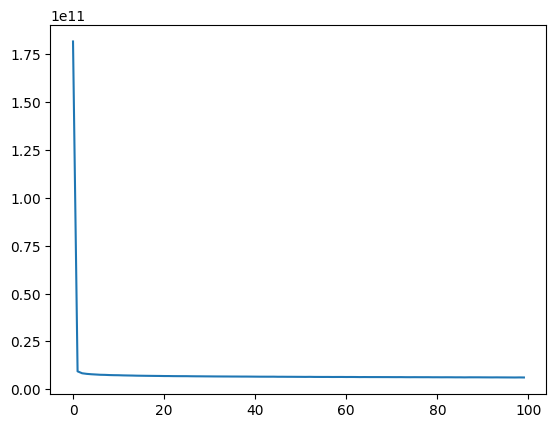

In [93]:
plt.plot (history.history['loss'])

### Early Stopping

In [94]:
df = pd.read_excel('cars.xls')

In [95]:
x=df.drop('Price', axis = 1)
y = df[['Price']]

In [96]:
x.head()

,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [97]:
x=pd.get_dummies(x,drop_first=True)

In [98]:
x=scaler.fit_transform(x) # normalization

In [99]:
model=Sequential()
model.add(Dense(64,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1)) #sigmoid yok
model.compile(loss='mean_squared_error', optimizer='adam')

In [101]:
from tensorflow.keras.callbacks import EarlyStopping

In [102]:
early_stop = EarlyStopping(
    monitor="val_loss",   # neyi izleyecek
    patience=10,           # kaç epoch sabredecek
)

In [103]:
history=model.fit(x_train,y_train, validation_data = (x_test, y_test),epochs=130, batch_size=32, callbacks=[early_stop],verbose=1)

Epoch 1/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 56112267264.0000 - val_loss: 10439274496.0000
Epoch 2/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8223785472.0000 - val_loss: 8772783104.0000
Epoch 3/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7944206336.0000 - val_loss: 8817674240.0000
Epoch 4/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7759241728.0000 - val_loss: 8243531776.0000
Epoch 5/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7651716096.0000 - val_loss: 8211496960.0000
Epoch 6/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7533373440.0000 - val_loss: 8156910080.0000
Epoch 7/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7342273024.0000 - val_loss: 8507059712.0000
Epoch 8/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7331749376.0000 - val_loss: 8529078272.0000
Epoch 9/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7324776448.0000 - val_loss: 8195314688.0000
Epoch 10/130
476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [104]:
tahmin = model.predict(x_test)

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [105]:
r2_score(y_test,tahmin)

0.8489667773246765

In [106]:
!pip install torch

In [111]:
import torch
import numpy as np

X_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_train = y_train.view(-1, 1)

# Model tanımı
class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # output
        )

    def forward(self, x):
        return self.net(x)

model = Model(X_train.shape[1])

# Loss ve optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early stopping parametreleri
patience = 10
best_loss = float("inf")
counter = 0

# Eğitim
epochs = 130
batch_size = 32

for epoch in range(epochs):
    model.train()

    permutation = torch.randperm(X_train.size()[0])

    for i in range(0, X_train.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train[indices], y_train[indices]

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)

    print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        best_model = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# en iyi modeli yükle
model.load_state_dict(best_model)

/tmp/ipykernel_13498/742420542.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_13498/742420542.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_test = torch.tensor(y_test, dtype=torch.float32)


Epoch 1, Train Loss: 3914599424.0000, Val Loss: 9692924928.0000
Epoch 2, Train Loss: 6657461248.0000, Val Loss: 9013483520.0000
Epoch 3, Train Loss: 12732858368.0000, Val Loss: 9715247104.0000
Epoch 4, Train Loss: 4540901376.0000, Val Loss: 8447763456.0000
Epoch 5, Train Loss: 3868521472.0000, Val Loss: 8356662272.0000
Epoch 6, Train Loss: 8867952640.0000, Val Loss: 8115330560.0000
Epoch 7, Train Loss: 7310504448.0000, Val Loss: 8173259776.0000
Epoch 8, Train Loss: 18249644032.0000, Val Loss: 8062023168.0000
Epoch 9, Train Loss: 9144009728.0000, Val Loss: 8159790592.0000
Epoch 10, Train Loss: 4121692160.0000, Val Loss: 8267610112.0000
Epoch 11, Train Loss: 5123695104.0000, Val Loss: 8102129664.0000
Epoch 12, Train Loss: 3271523840.0000, Val Loss: 8084490752.0000
Epoch 13, Train Loss: 3539423744.0000, Val Loss: 8195875840.0000
Epoch 14, Train Loss: 5076025856.0000, Val Loss: 8588633600.0000
Epoch 15, Train Loss: 3790705408.0000, Val Loss: 8292633600.0000
Epoch 16, Train Loss: 3285927936

<All keys matched successfully>